<a href="https://colab.research.google.com/github/Fariborz-Eshraghi/force-openvla/blob/main/OpenVLA03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenVLA 7B Google Colab T4 Demo

This notebook sets up a simple OpenVLA inference/playground test on Google Colab. It is designed for a Tesla T4 with about 15 GB VRAM, so it defaults to 4-bit bitsandbytes loading and avoids FlashAttention.

Sources used for this notebook:
- OpenVLA repo: https://github.com/openvla/openvla
- OpenVLA model card: https://huggingface.co/openvla/openvla-7b
- Hugging Face bitsandbytes quantization docs: https://huggingface.co/docs/transformers/quantization/bitsandbytes

Important: OpenVLA predicts robot actions in a robot-specific action space. The output here is useful for verifying that inference works, but it is not automatically executable on every robot hand or simulator without the right controller, calibration, and action unnormalization setup.

Run guid:

* Cell 1
* Cell 2
* Cell 3
* Runtime -> Restart runtime
* Cell 1
* Cell 2
* Cell 4
* Cell 5   <-- wait here until it fully finishes
* Cell 6   <-- now it should decode the AV1 video frame
* Cell 7
* Cell 8
* Cell 9



In [ ]:
# Clone the GitHub repo inside Colab
!git clone https://github.com/Fariborz-Eshraghi/force-vla-colab.git
%cd force-vla-colab

Cloning into 'force-vla-colab'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'force-vla-colab'
/content


In [1]:
# Cell 1: GPU check
# In Colab: Runtime -> Change runtime type -> GPU.
# Expected for your setup: NVIDIA Tesla T4 and CUDA available.

!nvidia-smi

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print("CUDA capability:", f"{major}.{minor}")
else:
    raise RuntimeError("CUDA is not available. In Colab, enable GPU runtime before continuing.")

Sun May 24 15:22:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 Notes: Hugging Face Token Setup

1. Go to https://huggingface.co/settings/tokens
2. Click **Create new token**.
3. Choose **Read** access. A fine-grained read token is enough for downloading public or accessible models.
4. Copy the token once. It starts with `hf_...`.
5. In Colab, do not hardcode it in the notebook. Use `login()` and paste it into the secure prompt.

Optional Colab Secrets path: click the key icon in Colab's left sidebar, add a secret named `HF_TOKEN`, and then use the commented code below.

In [2]:
# Cell 2: Hugging Face login
# Do not paste or save your token directly in this notebook.
# This opens a secure prompt in Colab.

from huggingface_hub import login

login()

# Optional Colab Secrets version:
#from google.colab import userdata
#hf_token = userdata.get("HF_TOKEN")
#login(token=hf_token)

In [5]:
# Cell 3: Minimal pinned dependencies for OpenVLA + direct BridgeData access
# Do NOT install lerobot. It changes torch/huggingface_hub dependencies.

%pip install -q --upgrade \
  "transformers==4.49.0" \
  "tokenizers>=0.21,<0.22" \
  "timm==0.9.10" \
  "accelerate==1.1.1" \
  "bitsandbytes>=0.45.5" \
  "huggingface_hub==0.34.6" \
  "requests==2.32.4" \
  "fsspec==2025.3.0" \
  "pillow<12,>=10.0.0" \
  "einops" \
  "av==15.0.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.6/562.6 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


In [3]:
# Cell 4: Import checks

import importlib.metadata as md
import torch
import torchvision
import transformers
import accelerate
import bitsandbytes as bnb
import timm
import tokenizers
import PIL
import huggingface_hub
import pandas as pd
import av

packages = [
    "torch",
    "torchvision",
    "transformers",
    "accelerate",
    "bitsandbytes",
    "huggingface_hub",
    "requests",
    "fsspec",
    "Pillow",
    "einops",
    "timm",
    "tokenizers",
    "pandas",
    "av",

]

for name in packages:
    try:
        print(f"{name}: {md.version(name)}")
    except md.PackageNotFoundError:
        print(f"{name}: not found")

print("\nCUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nCritical compatibility check:")
print("huggingface_hub must be < 1.0 for transformers==4.49.0")
print("huggingface_hub:", huggingface_hub.__version__)


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
transformers: 4.49.0
accelerate: 1.1.1
bitsandbytes: 0.49.2
huggingface_hub: 0.34.6
requests: 2.32.4
fsspec: 2025.3.0
Pillow: 11.3.0
einops: 0.8.2
timm: 0.9.10
tokenizers: 0.21.4
pandas: 2.2.2
av: 15.0.0

CUDA available: True
GPU: Tesla T4

Critical compatibility check:
huggingface_hub must be < 1.0 for transformers==4.49.0
huggingface_hub: 0.34.6


In [4]:
# Cell 5: Load processor/model efficiently
# Default: 4-bit quantized OpenVLA 7B for a Tesla T4.
# This can take several minutes the first time because the model weights are downloaded. -> 5m on T4

import gc
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor, BitsAndBytesConfig

MODEL_ID = "openvla/openvla-7b"
UNNORM_KEY = "bridge_orig"
COMPUTE_DTYPE = torch.float16  # T4 supports fp16. T4 does not support bf16 well.

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def gpu_memory(label):
    if not torch.cuda.is_available():
        print(f"{label}: CUDA is not available")
        return
    free, total = torch.cuda.mem_get_info()
    allocated = torch.cuda.memory_allocated()
    reserved = torch.cuda.memory_reserved()
    print(f"{label} GPU memory")
    print(f"  free:      {free / 1024**3:.2f} GiB / {total / 1024**3:.2f} GiB")
    print(f"  allocated: {allocated / 1024**3:.2f} GiB")
    print(f"  reserved:  {reserved / 1024**3:.2f} GiB")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Enable a GPU runtime before loading OpenVLA.")

cleanup_memory()
gpu_memory("Before loading")

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

vla = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    attn_implementation="eager",
    torch_dtype=COMPUTE_DTYPE,
    quantization_config=quantization_config,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

vla.eval()


gpu_memory("After loading")
print("Device map:", getattr(vla, "hf_device_map", "No device_map attribute"))

try:
    print(f"Model memory footprint: {vla.get_memory_footprint() / 1024**3:.2f} GiB")
except Exception as exc:
    print("Could not read model memory footprint:", repr(exc))

Before loading GPU memory
  free:      14.46 GiB / 14.56 GiB
  allocated: 0.00 GiB
  reserved:  0.00 GiB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openvla/openvla-7b:
- processing_prismatic.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/6.97G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

After loading GPU memory
  free:      10.24 GiB / 14.56 GiB
  allocated: 4.05 GiB
  reserved:  4.21 GiB
Device map: {'': 0}
Model memory footprint: 3.88 GiB


Number of repo files: 265966


info.json: 0.00B [00:00, ?B/s]

Robot type: widowx
FPS: 5
Features:
  observation.images.image_3 -> {'dtype': 'video', 'shape': [256, 256, 3], 'names': ['height', 'width', 'rgb'], 'info': {'video.fps': 5.0, 'video.height': 256, 'video.width': 256, 'video.channels': 3, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'has_audio': False}}
  observation.images.image_2 -> {'dtype': 'video', 'shape': [256, 256, 3], 'names': ['height', 'width', 'rgb'], 'info': {'video.fps': 5.0, 'video.height': 256, 'video.width': 256, 'video.channels': 3, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'has_audio': False}}
  observation.images.image_1 -> {'dtype': 'video', 'shape': [256, 256, 3], 'names': ['height', 'width', 'rgb'], 'info': {'video.fps': 5.0, 'video.height': 256, 'video.width': 256, 'video.channels': 3, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'has_audio': False}}
  observation.images.image_0 -> {'dtype': 'video', 'shape': [

data/chunk-000/episode_000000.parquet:   0%|          | 0.00/5.73k [00:00<?, ?B/s]


Parquet shape: (26, 7)
Columns:
  observation.state
  action
  timestamp
  frame_index
  episode_index
  index
  task_index

Selected row:
observation.state    [0.29659736, 0.08721913, 0.090906665, 0.422019...
action               [-0.00068077445, -0.0024188012, -0.014155045, ...
timestamp                                                          0.0
frame_index                                                          0
episode_index                                                        0
index                                                                0
task_index                                                           0
Name: 0, dtype: object

Ground-truth action shape: (7,)
Ground-truth action: [-0.000680774450302124, -0.002418801188468933, -0.01415504515171051, -0.026210248470306396, 0.024769984185695648, 0.05495709180831909, 1.0]


tasks.jsonl: 0.00B [00:00, ?B/s]


Instruction: put small spoon from basket to tray

Video keys: ['observation.images.image_3', 'observation.images.image_2', 'observation.images.image_1', 'observation.images.image_0']
Episode index: 0
Frame index: 0
Selected video file: videos/chunk-000/observation.images.image_0/episode_000000.mp4


videos/chunk-000/observation.images.imag(…):   0%|          | 0.00/254k [00:00<?, ?B/s]

Image size: (256, 256)


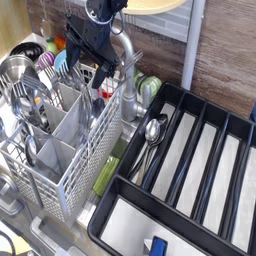

In [5]:
# Cell 6: Load one real BridgeData frame directly from Hugging Face

import json
import re
import pandas as pd
import numpy as np
import av
from PIL import Image
from IPython.display import display
from huggingface_hub import hf_hub_download, list_repo_files

REAL_DATASET_ID = "IPEC-COMMUNITY/bridge_orig_lerobot"
REAL_FILE_INDEX = 0
REAL_ROW_INDEX = 0

# List repository files
repo_files = list_repo_files(
    repo_id=REAL_DATASET_ID,
    repo_type="dataset",
)

print("Number of repo files:", len(repo_files))

# Download metadata
info_path = hf_hub_download(
    repo_id=REAL_DATASET_ID,
    repo_type="dataset",
    filename="meta/info.json",
)

with open(info_path, "r") as f:
    info = json.load(f)

print("Robot type:", info.get("robot_type"))
print("FPS:", info.get("fps"))
print("Features:")
for k, v in info.get("features", {}).items():
    print(" ", k, "->", v)

# Pick a parquet data file
parquet_files = sorted([f for f in repo_files if f.startswith("data/") and f.endswith(".parquet")])
print("\nNumber of parquet files:", len(parquet_files))
print("First parquet file:", parquet_files[REAL_FILE_INDEX])

parquet_path = hf_hub_download(
    repo_id=REAL_DATASET_ID,
    repo_type="dataset",
    filename=parquet_files[REAL_FILE_INDEX],
)

df = pd.read_parquet(parquet_path)
print("\nParquet shape:", df.shape)
print("Columns:")
for col in df.columns:
    print(" ", col)

row = df.iloc[REAL_ROW_INDEX]

print("\nSelected row:")
print(row)

# Extract action
gt_action = np.asarray(row["action"], dtype=np.float32).reshape(-1)

print("\nGround-truth action shape:", gt_action.shape)
print("Ground-truth action:", gt_action.tolist())

# Extract task instruction if present
instruction = "perform the next robot manipulation action"

if "task_index" in row:
    try:
        tasks_path = hf_hub_download(
            repo_id=REAL_DATASET_ID,
            repo_type="dataset",
            filename="meta/tasks.jsonl",
        )
        with open(tasks_path, "r") as f:
            tasks = [json.loads(line) for line in f]

        task_index = int(row["task_index"])
        matching = [t for t in tasks if int(t.get("task_index", -1)) == task_index]

        if len(matching) > 0:
            instruction = matching[0].get("task", instruction)
    except Exception as exc:
        print("Could not load task text:", repr(exc))

print("\nInstruction:", instruction)

# Discover video keys from info.json
features = info.get("features", {})
video_keys = [
    k for k, v in features.items()
    if isinstance(v, dict) and (v.get("dtype") == "video" or "video" in str(v).lower())
]

# Fallback: inspect repo videos
if len(video_keys) == 0:
    video_files = sorted([f for f in repo_files if f.startswith("videos/") and f.endswith(".mp4")])
    print("\nNo video key found in info.json. First video file:", video_files[0])
else:
    print("\nVideo keys:", video_keys)

video_files = sorted([f for f in repo_files if f.startswith("videos/") and f.endswith(".mp4")])
if len(video_files) == 0:
    raise RuntimeError("No video files found in dataset repo.")

episode_index = int(row["episode_index"]) if "episode_index" in row else 0
frame_index = int(row["frame_index"]) if "frame_index" in row else REAL_ROW_INDEX

print("Episode index:", episode_index)
print("Frame index:", frame_index)

# Find a video path matching this episode.
episode_patterns = [
    f"episode_{episode_index:06d}.mp4",
    f"episode_{episode_index}.mp4",
]

matching_videos = [
    f for f in video_files
    if any(pattern in f for pattern in episode_patterns)
]

if len(matching_videos) == 0:
    print("Could not find exact episode video. Falling back to first video file.")
    video_file = video_files[0]
else:
    video_file = matching_videos[0]

print("Selected video file:", video_file)

video_path = hf_hub_download(
    repo_id=REAL_DATASET_ID,
    repo_type="dataset",
    filename=video_file,
)

# Read selected frame from AV1 video using PyAV.
# OpenCV often fails on these BridgeData AV1 videos in Colab.

def read_video_frame_pyav(video_path, target_frame_index):
    target_frame_index = int(target_frame_index)

    with av.open(video_path) as container:
        stream = container.streams.video[0]

        for decoded_index, frame in enumerate(container.decode(stream)):
            if decoded_index == target_frame_index:
                frame_rgb = frame.to_ndarray(format="rgb24")
                return Image.fromarray(frame_rgb).convert("RGB")

    raise RuntimeError(
        f"Could not decode frame {target_frame_index} from {video_path}. "
        "Try a smaller frame_index or another episode."
    )

image = read_video_frame_pyav(video_path, frame_index)


print("Image size:", image.size)
display(image)


In [6]:
# Cell 7: Create OpenVLA prompt for the real Bridge frame

prompt = f"In: What action should the robot take to {instruction}?\nOut: "

print("Instruction:", instruction)
print("Prompt:")
print(repr(prompt))


Instruction: put small spoon from basket to tray
Prompt:
'In: What action should the robot take to put small spoon from basket to tray?\nOut: '


In [7]:
# Cell 8: Run OpenVLA on real BridgeData image

import time
import numpy as np
import torch

device = "cuda:0"

inputs = processor(prompt, image).to(device, dtype=COMPUTE_DTYPE)

print("Processor output keys:", list(inputs.keys()))
for key, value in inputs.items():
    if hasattr(value, "shape"):
        print(f"  {key}: shape={tuple(value.shape)}, dtype={value.dtype}, device={value.device}")

with torch.inference_mode():
    start = time.time()

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        pred_action = vla.predict_action(
            **inputs,
            unnorm_key=UNNORM_KEY,
            do_sample=False,
            use_cache=False,
        )

    elapsed = time.time() - start

pred_action = np.asarray(pred_action, dtype=np.float32).reshape(-1)
action = pred_action

print("\nInstruction:", instruction)
print("Image size:", image.size)
print("Ground-truth dataset action:", gt_action.tolist())
print("OpenVLA predicted action:  ", pred_action.tolist())
print("Prediction shape:", pred_action.shape)
print(f"Inference time: {elapsed:.2f} seconds")

gpu_memory("After real-data inference")


Processor output keys: ['input_ids', 'attention_mask', 'pixel_values']
  input_ids: shape=(1, 24), dtype=torch.int64, device=cuda:0
  attention_mask: shape=(1, 24), dtype=torch.int64, device=cuda:0
  pixel_values: shape=(1, 6, 224, 224), dtype=torch.float16, device=cuda:0

Instruction: put small spoon from basket to tray
Image size: (256, 256)
Ground-truth dataset action: [-0.000680774450302124, -0.002418801188468933, -0.01415504515171051, -0.026210248470306396, 0.024769984185695648, 0.05495709180831909, 1.0]
OpenVLA predicted action:   [0.004935720004141331, 0.008317392319440842, -0.015311109833419323, 0.004969872999936342, 0.00792764313519001, -0.029079075902700424, 0.9960784316062927]
Prediction shape: (7,)
Inference time: 6.07 seconds
After real-data inference GPU memory
  free:      9.76 GiB / 14.56 GiB
  allocated: 4.06 GiB
  reserved:  4.67 GiB


In [8]:
# Cell 8B: Accurate OpenVLA model-only forward/inference timing

import time
import numpy as np
import torch

# Inputs are already prepared here, outside timing.
inputs = processor(prompt, image).to(device, dtype=COMPUTE_DTYPE)

# Warmup: first run is often slower because CUDA kernels initialize.
with torch.inference_mode():
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        _ = vla.predict_action(
            **inputs,
            unnorm_key=UNNORM_KEY,
            do_sample=False,
            use_cache=False,
        )

if torch.cuda.is_available():
    torch.cuda.synchronize()

times = []
N = 10

for i in range(N):
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            _action = vla.predict_action(
                **inputs,
                unnorm_key=UNNORM_KEY,
                do_sample=False,
                use_cache=False,
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    times.append(elapsed)

    print(f"Run {i+1}: model-only time = {elapsed:.4f} sec")

times = np.array(times)

print("\nOpenVLA model-only timing:")
print(f"Mean:   {times.mean():.4f} sec")
print(f"Median: {np.median(times):.4f} sec")
print(f"Min:    {times.min():.4f} sec")
print(f"Max:    {times.max():.4f} sec")
print(f"Std:    {times.std():.4f} sec")
print(f"Hz:     {1.0 / times.mean():.2f} actions/sec")


Run 1: model-only time = 4.7882 sec
Run 2: model-only time = 4.9263 sec
Run 3: model-only time = 4.9737 sec
Run 4: model-only time = 4.9489 sec
Run 5: model-only time = 4.7294 sec
Run 6: model-only time = 4.6562 sec
Run 7: model-only time = 4.6620 sec
Run 8: model-only time = 4.4760 sec
Run 9: model-only time = 4.5384 sec
Run 10: model-only time = 4.4482 sec

OpenVLA model-only timing:
Mean:   4.7147 sec
Median: 4.6957 sec
Min:    4.4482 sec
Max:    4.9737 sec
Std:    0.1837 sec
Hz:     0.21 actions/sec


Ground-truth action:
  delta_x     : -0.000681
  delta_y     : -0.002419
  delta_z     : -0.014155
  delta_roll  : -0.026210
  delta_pitch :  0.024770
  delta_yaw   :  0.054957
  gripper     :  1.000000

OpenVLA predicted action:
  delta_x     :  0.004936
  delta_y     :  0.008317
  delta_z     : -0.015311
  delta_roll  :  0.004970
  delta_pitch :  0.007928
  delta_yaw   : -0.029079
  gripper     :  0.996078

Error: predicted - ground truth
  delta_x     :  0.005616
  delta_y     :  0.010736
  delta_z     : -0.001156
  delta_roll  :  0.031180
  delta_pitch : -0.016842
  delta_yaw   : -0.084036
  gripper     : -0.003922

Simple metrics:
  L2 error: 0.092095
  XYZ movement cosine similarity: 0.7422


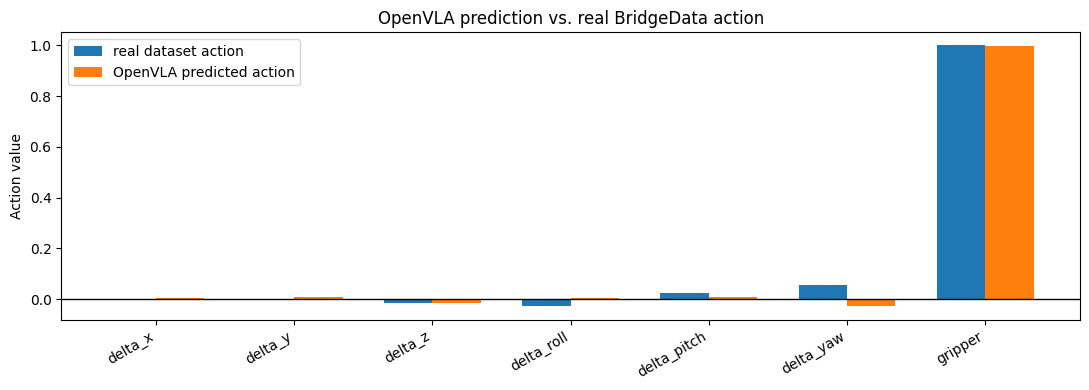

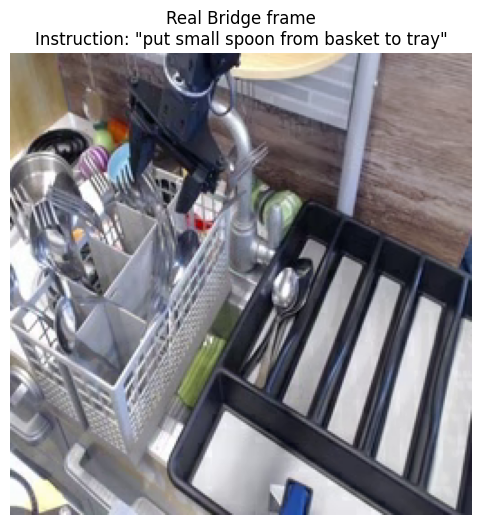

In [9]:
# Cell 9: Compare OpenVLA prediction with real dataset action

import numpy as np
import matplotlib.pyplot as plt

gt = np.asarray(gt_action, dtype=np.float32).reshape(-1)
pred = np.asarray(pred_action, dtype=np.float32).reshape(-1)

labels = [
    "delta_x",
    "delta_y",
    "delta_z",
    "delta_roll",
    "delta_pitch",
    "delta_yaw",
    "gripper",
]

if gt.shape[0] != pred.shape[0]:
    raise ValueError(f"Shape mismatch: gt={gt.shape}, pred={pred.shape}")

error = pred - gt
l2_error = float(np.linalg.norm(error))

move_gt = gt[:3]
move_pred = pred[:3]

move_cosine = float(
    np.dot(move_gt, move_pred) /
    (np.linalg.norm(move_gt) * np.linalg.norm(move_pred) + 1e-8)
)

print("Ground-truth action:")
for label, value in zip(labels, gt):
    print(f"  {label:12s}: {value: .6f}")

print("\nOpenVLA predicted action:")
for label, value in zip(labels, pred):
    print(f"  {label:12s}: {value: .6f}")

print("\nError: predicted - ground truth")
for label, value in zip(labels, error):
    print(f"  {label:12s}: {value: .6f}")

print("\nSimple metrics:")
print(f"  L2 error: {l2_error:.6f}")
print(f"  XYZ movement cosine similarity: {move_cosine:.4f}")

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(11, 4))
plt.bar(x - width / 2, gt, width, label="real dataset action")
plt.bar(x + width / 2, pred, width, label="OpenVLA predicted action")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Action value")
plt.title("OpenVLA prediction vs. real BridgeData action")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f'Real Bridge frame\nInstruction: "{instruction}"')
plt.axis("off")
plt.show()


In [ ]:
# Cell 9A: Compare OpenVLA prediction to future action horizons

import numpy as np

def get_action_from_df_row(i):
    return np.asarray(df.iloc[i]["action"], dtype=np.float32).reshape(-1)

def compare_to_action(target_action, name):
    target_action = np.asarray(target_action, dtype=np.float32).reshape(-1)
    pred = np.asarray(pred_action, dtype=np.float32).reshape(-1)

    err = pred - target_action
    l2 = float(np.linalg.norm(err))

    cosine_xyz = float(
        np.dot(pred[:3], target_action[:3]) /
        (np.linalg.norm(pred[:3]) * np.linalg.norm(target_action[:3]) + 1e-8)
    )

    print(f"\n{name}")
    print(f"L2 error: {l2:.6f}")
    print(f"XYZ cosine similarity: {cosine_xyz:.4f}")
    print("Target action:", target_action.tolist())
    print("Pred action:  ", pred.tolist())

# Immediate single-step action, same as before
compare_to_action(gt_action, "Immediate ground truth action, 1 step = 0.2 sec")

# Average over next few future actions in same episode
for horizon in [3, 5, 10, 25]:
    end = min(REAL_ROW_INDEX + horizon, len(df))
    future_actions = np.stack(
        [get_action_from_df_row(i) for i in range(REAL_ROW_INDEX, end)],
        axis=0,
    )

    avg_future_action = future_actions.mean(axis=0)
    seconds = future_actions.shape[0] / info["fps"]

    compare_to_action(
        avg_future_action,
        f"Average future action over {future_actions.shape[0]} steps = {seconds:.1f} sec",
    )


In [ ]:
# Cell 9B: Split metrics by translation, rotation, and gripper

import numpy as np

def split_metrics(target_action, name):
    target = np.asarray(target_action, dtype=np.float32).reshape(-1)
    pred = np.asarray(pred_action, dtype=np.float32).reshape(-1)

    xyz_err = float(np.linalg.norm(pred[:3] - target[:3]))
    rot_err = float(np.linalg.norm(pred[3:6] - target[3:6]))
    grip_err = float(abs(pred[6] - target[6]))

    xyz_cos = float(
        np.dot(pred[:3], target[:3]) /
        (np.linalg.norm(pred[:3]) * np.linalg.norm(target[:3]) + 1e-8)
    )

    print(f"\n{name}")
    print(f"XYZ L2 error:      {xyz_err:.6f}")
    print(f"XYZ cosine:        {xyz_cos:.4f}")
    print(f"Rotation L2 error: {rot_err:.6f}")
    print(f"Gripper error:     {grip_err:.6f}")

split_metrics(gt_action, "Immediate 1-step target")

for horizon in [3, 5, 10, 25]:
    end = min(REAL_ROW_INDEX + horizon, len(df))
    future_actions = np.stack(
        [get_action_from_df_row(i) for i in range(REAL_ROW_INDEX, end)],
        axis=0,
    )
    avg_future_action = future_actions.mean(axis=0)
    seconds = future_actions.shape[0] / info["fps"]

    split_metrics(avg_future_action, f"Average future target over {seconds:.1f} sec")


In [ ]:
# Cell 9D: Visualize tactile contact vs proximity

import matplotlib.pyplot as plt
import numpy as np

normal = tactile_now[:, 0]
shear_mag = np.linalg.norm(tactile_now[:, 1:3], axis=1)
proximity = tactile_proximity

x = np.arange(len(finger_order))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.25, normal, width=0.25, label="normal force")
plt.bar(x, shear_mag, width=0.25, label="shear force")
plt.bar(x + 0.25, proximity, width=0.25, label="proximity, not force", alpha=0.55)

plt.xticks(x, finger_order, rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Value")
plt.title("Synthetic tactile readings: contact force vs proximity")
plt.legend()
plt.tight_layout()
plt.show()


## Performance Notes

- A Tesla T4 with 15 GB VRAM is generally not enough for comfortable full precision OpenVLA 7B inference. Use 4-bit loading first.
- Inference may be slow on a T4, especially the first call after loading. Expect seconds per action, not real-time control.
- This notebook is only a simple one-shot inference demo. It is not a closed-loop robot simulation.
- Real robot control would require camera integration, safety limits, action unnormalization for the correct robot/dataset, and a low-level controller. OpenVLA is the high-level action prediction component, not the whole robot stack.

In [15]:
# Final cell: Save this current Colab notebook to GitHub
# Target repo: Fariborz-Eshraghi/force-openvla
# Target path: notebooks/OpenVLA03.ipynb

import base64
import json
import requests
from datetime import datetime

from google.colab import userdata
from google.colab import _message

GITHUB_OWNER = "Fariborz-Eshraghi"
GITHUB_REPO = "force-openvla"
GITHUB_BRANCH = "main"

NOTEBOOK_FILENAME = "OpenVLA03.ipynb"
GITHUB_PATH = f"notebooks/{NOTEBOOK_FILENAME}"

github_token = userdata.get("GITHUB_TOKEN")

if github_token is None:
    raise RuntimeError(
        "GITHUB_TOKEN was not found in Colab Secrets. "
        "Add it in the Colab Secrets panel, then rerun this cell."
    )

# Get the current notebook content directly from Colab.
notebook_data = _message.blocking_request("get_ipynb", timeout_sec=120)["ipynb"]

notebook_json = json.dumps(notebook_data, indent=2, ensure_ascii=False)
encoded_content = base64.b64encode(notebook_json.encode("utf-8")).decode("utf-8")

headers = {
    "Authorization": f"Bearer {github_token}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
}

contents_url = (
    f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}"
    f"/contents/{GITHUB_PATH}"
)

# Check whether the file already exists, because GitHub needs its SHA to update it.
get_response = requests.get(
    contents_url,
    headers=headers,
    params={"ref": GITHUB_BRANCH},
)

sha = None

if get_response.status_code == 200:
    sha = get_response.json()["sha"]
    print(f"Existing file found on GitHub: {GITHUB_PATH}")
elif get_response.status_code == 404:
    print(f"File does not exist yet. It will be created: {GITHUB_PATH}")
else:
    raise RuntimeError(
        f"Could not check existing file. "
        f"Status: {get_response.status_code}\n{get_response.text}"
    )

commit_message = (
    f"Update {NOTEBOOK_FILENAME} from Colab "
    f"({datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC)"
)

payload = {
    "message": commit_message,
    "content": encoded_content,
    "branch": GITHUB_BRANCH,
}

if sha is not None:
    payload["sha"] = sha

put_response = requests.put(
    contents_url,
    headers=headers,
    json=payload,
)

if put_response.status_code not in [200, 201]:
    raise RuntimeError(
        f"GitHub upload failed. "
        f"Status: {put_response.status_code}\n{put_response.text}"
    )

result = put_response.json()

print("Notebook saved to GitHub successfully.")
print("Commit message:", commit_message)
print("GitHub path:", GITHUB_PATH)
print("URL:", result["content"]["html_url"])

SecretNotFoundError: Secret GITHUB_TOKEN does not exist.